# 📈 Model Evaluation & Hyperparameter Tuning

## Objective

This notebook evaluates the performance of all trained regression models using multiple regression metrics.

The best-performing model is further optimized using hyperparameter tuning and saved for deployment.

In [1]:
import pandas as pd
import numpy as np
import joblib

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from xgboost import XGBRegressor

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("../data/processed/train_featured.csv")

X = df.drop("trip_duration", axis=1)
y = df["trip_duration"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [3]:
linear_model = joblib.load("../models/linear_regression.pkl")
decision_tree_model = joblib.load("../models/decision_tree.pkl")
random_forest_model = joblib.load("../models/random_forest.pkl")
xgb_model = joblib.load("../models/xgboost.pkl")

In [4]:
def evaluate_model(model, X_test, y_test):

    prediction = model.predict(X_test)

    mae = mean_absolute_error(y_test, prediction)

    rmse = np.sqrt(mean_squared_error(y_test, prediction))

    r2 = r2_score(y_test, prediction)

    return mae, rmse, r2

In [5]:
results = []

models = {
    "Linear Regression": linear_model,
    "Decision Tree": decision_tree_model,
    "Random Forest": random_forest_model,
    "XGBoost": xgb_model
}

for model_name, model in models.items():

    mae, rmse, r2 = evaluate_model(model, X_test, y_test)

    results.append({
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(by="RMSE")

results_df

,Model,MAE,RMSE,R2 Score
3,XGBoost,177.603607,307.458483,0.786925
2,Random Forest,184.713778,317.621990,0.772605
1,Decision Tree,207.433300,360.604530,0.706895
0,Linear Regression,273.372636,419.708234,0.602941


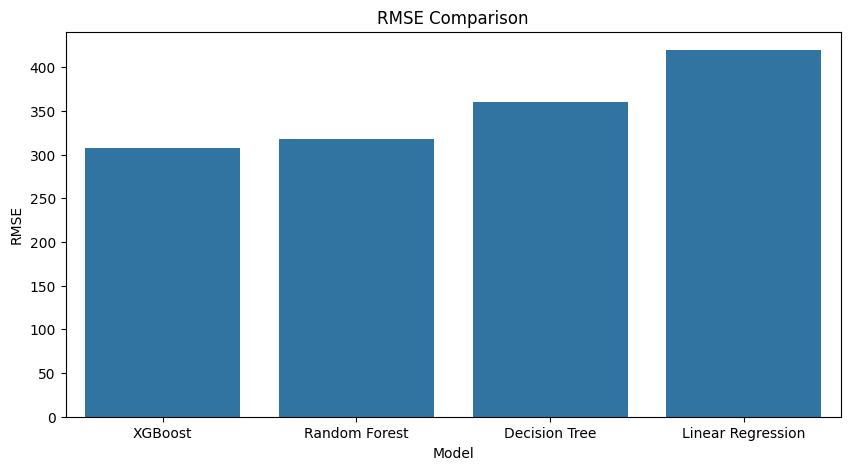

In [6]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=results_df,
    x="Model",
    y="RMSE"
)

plt.title("RMSE Comparison")

plt.show()

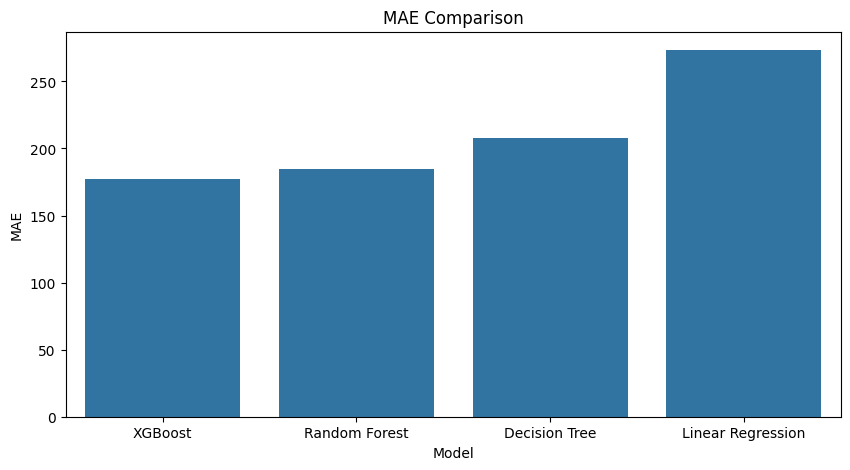

In [7]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=results_df,
    x="Model",
    y="MAE"
)

plt.title("MAE Comparison")

plt.show()

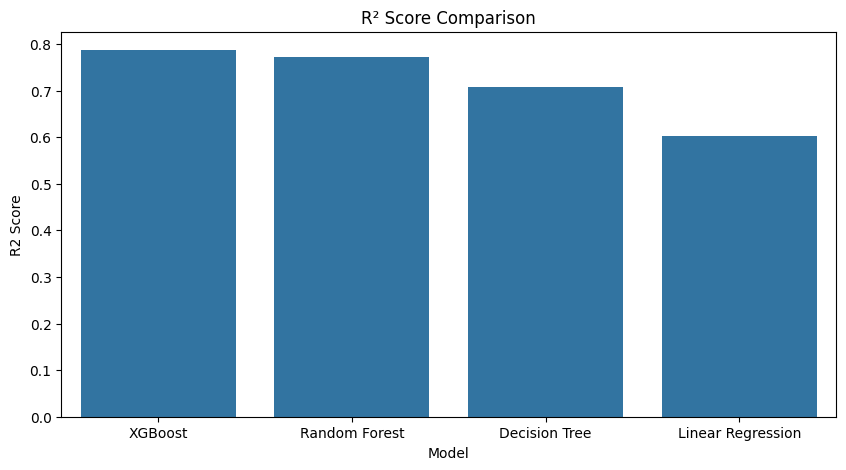

In [8]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=results_df,
    x="Model",
    y="R2 Score"
)

plt.title("R² Score Comparison")

plt.show()

## Best Model

The model with the **lowest RMSE** and **highest R² Score** is selected for further optimization.

In [9]:
best_model_name = results_df.iloc[0]["Model"]

print("Best Model:", best_model_name)

Best Model: XGBoost


In [10]:
param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [4, 6, 8, 10],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0]
}

In [11]:
random_search = RandomizedSearchCV(
    estimator=XGBRegressor(
        objective="reg:squarederror",
        random_state=42
    ),
    param_distributions=param_dist,
    n_iter=20,
    scoring="neg_root_mean_squared_error",
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


,estimator,"XGBRegressor(...ree=None, ...)"
,param_distributions,"{'colsample_bytree': [0.7, 0.8, ...], 'learning_rate': [0.01, 0.03, ...], 'max_depth': [4, 6, ...], 'n_estimators': [100, 200, ...], ...}"
,n_iter,20
,scoring,'neg_root_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [12]:
print("Best Parameters:")
print(random_search.best_params_)

print("\nBest CV Score:")
print(random_search.best_score_)

Best Parameters:
{'subsample': 1.0, 'n_estimators': 500, 'max_depth': 10, 'learning_rate': 0.05, 'colsample_bytree': 0.8}

Best CV Score:
-284.2552897135417


In [13]:
best_model = random_search.best_estimator_

In [14]:

prediction = best_model.predict(X_test)

print("MAE :", mean_absolute_error(y_test, prediction))
print("RMSE :", np.sqrt(mean_squared_error(y_test, prediction)))
print("R² :", r2_score(y_test, prediction))

MAE : 168.67845153808594
RMSE : 296.8573021040581
R² : 0.801365077495575


In [15]:
joblib.dump(best_model, "../models/best_model.pkl")

print("Optimized model saved successfully!")

Optimized model saved successfully!
